## MedDec Decision Extraction, LLM Based | Colab Notebook

**Goal**: Run the zero-shot and one-shot promps through LLM pipelines to detect medical decision spans. Experiments with a seq2seq model `FLAN-T5` and a causal language model `Llama-3-8B`

## Step 0. Setup

In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [2]:
# sentencepiece (FLAN-T5 tokeniser)
# accelerate is required for device_map='auto' (Llama-3)
!pip install -q transformers sentencepiece accelerate

In [ ]:
!pip install python-dotenv

In [3]:
import shutil, sys
from pathlib import Path
from dotenv import load_dotenv

# EDIT PATHS
DRIVE_CODE_DIR = Path("/content/drive/MyDrive/AI4H-project-rework/04 Code/04 Code/med-decision-extraction")
DRIVE_DATA_DIR = Path("/content/drive/MyDrive/AI4H-project-rework/02 Data")
ENV_DIR = Path("/content/drive/MyDrive/AI4H-project-rework/04 Code/04 Code/.env")

LOCAL_CODE = Path("/content/meddec")
if LOCAL_CODE.exists():
    shutil.rmtree(LOCAL_CODE)
shutil.copytree(DRIVE_CODE_DIR, LOCAL_CODE)
sys.path.insert(0, str(LOCAL_CODE))

MEDDEC_DIR  = DRIVE_DATA_DIR / "meddec-mimic-iii"
SPLITS_DIR  = MEDDEC_DIR / "splits"
GENS_DIR    = DRIVE_DATA_DIR / "gens"   # predictions saved here (persisted to Drive)
GENS_DIR.mkdir(parents=True, exist_ok=True)

load_dotenv(ENV_DIR)

print("Code :", LOCAL_CODE)
print("Data :", MEDDEC_DIR)

Code : /content/meddec
Data : /content/drive/MyDrive/AI4H-project-rework/02 Data/meddec-mimic-iii


## Step 0b. Verify GPU + data, pick LLM model

In [4]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU   :", torch.cuda.get_device_name(0))
    print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

n_json = len(list((MEDDEC_DIR / "data").glob("*.json")))
n_txt  = len(list((MEDDEC_DIR / "raw_text").glob("*.txt")))
print(f"\nJSON annotations : {n_json}")
print(f"Raw text files   : {n_txt}")
print(f"Test split size  : {len((SPLITS_DIR / 'test.txt').read_text().splitlines())} notes")

Device: cuda
GPU   : Tesla T4
VRAM  : 15.6 GB

JSON annotations : 403
Raw text files   : 403
Test split size  : 41 notes


In [5]:
# Pick seq2seq FLAN-T5 model
MODEL_NAME = "google/flan-t5-xl"

#"google/flan-t5-small"   # ~0.3 GB  — fast test, weakest quality
#"google/flan-t5-base"  # ~1 GB    — better quality, still fast on T4
#"google/flan-t5-xl"    # ~12 GB   — best free-tier quality

In [ ]:
# Set Llama-3 model (TBD)
import os
hf_token = os.getenv("HF_TOKEN")
MODEL_NAME = "meta-llama/Llama-3.2-3B-Instruct"

# MODEL_NAME = "meta-llama/Meta-Llama-3-8B-Instruct"  # ~16 GB might not work on Colab T4 free tier
# For Llama-3, set your HuggingFace token (request access at huggingface.co first)
# import os; os.environ["HF_TOKEN"] = "hf_..."

print(f"Selected model: {MODEL_NAME}")

## Seq2Seq generative model (FLAN-T5)

### Step 1. Zero-shot generation

For each note and for each of the 9 categories, give the zero shot prompt to the LLM with the noteattached

In [6]:
from gen_span_detection import run_pipeline

# Save output of detected spans for each note here
ZERO_SHOT_DIR = GENS_DIR / "test_zero_shot"

run_pipeline(meddec_dir = MEDDEC_DIR,
    splits_dir = SPLITS_DIR,
    model_name = MODEL_NAME,
    output_dir = ZERO_SHOT_DIR,
    split      = "test",
    mode       = "zero_shot",
    #max_samples = 5,   # uncomment to process only x notes for testing
)

Loading google/flan-t5-xl on cuda ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.44k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

...

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

  Model type : seq2seq
  Parameters : 2850M


zero_shot | test: 100%|██████████| 41/41 [31:41<00:00, 46.38s/it]


Done. Skipped 0 files. Results in /content/drive/MyDrive/AI4H-project-rework/02 Data/gens/test_zero_shot


### Step 2. One-shot generation

Same pipeline, but each prompt now includes one example drawn from the **same note's annotations**.  
(note: The example's category is whichever category has the most spans in that note and is always different from the target category).

In [7]:
from gen_span_detection import run_pipeline

# Save output of detected spans for each note here
ONE_SHOT_DIR = GENS_DIR / "test_one_shot"

run_pipeline(
    meddec_dir = MEDDEC_DIR,
    splits_dir = SPLITS_DIR,
    model_name = MODEL_NAME,
    output_dir = ONE_SHOT_DIR,
    split      = "test",
    mode       = "one_shot",
    # max_samples = 5,
)

Loading google/flan-t5-xl on cuda ...


Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


  Model type : seq2seq
  Parameters : 2850M


one_shot | test: 100%|██████████| 41/41 [32:41<00:00, 47.84s/it]


Done. Skipped 0 files. Results in /content/drive/MyDrive/AI4H-project-rework/02 Data/gens/test_one_shot


### Step 3. Evaluation
Methods:
- **em** (exact match): `pred.strip() == gold.strip()`
- **approx-m**: one is a substring of the other AND word count difference ≤ 10

In [9]:
from eval_gen import evaluate_predictions, print_results

TEST_SPLIT_FILE = SPLITS_DIR / "test.txt"

results_zero_em     = evaluate_predictions(MEDDEC_DIR, TEST_SPLIT_FILE, ZERO_SHOT_DIR, method="em")
results_zero_approx = evaluate_predictions(MEDDEC_DIR, TEST_SPLIT_FILE, ZERO_SHOT_DIR, method="approx-m")
results_one_em      = evaluate_predictions(MEDDEC_DIR, TEST_SPLIT_FILE, ONE_SHOT_DIR,  method="em")
results_one_approx  = evaluate_predictions(MEDDEC_DIR, TEST_SPLIT_FILE, ONE_SHOT_DIR,  method="approx-m")

Gold triples : 5188
Pred triples : 310
Gold triples : 5188
Pred triples : 310
Gold triples : 5188
Pred triples : 285
Gold triples : 5188
Pred triples : 285


In [10]:
print_results(results_zero_em,     label="Zero-shot | EM")
print_results(results_zero_approx, label="Zero-shot | Approx-M")
print_results(results_one_em,      label="One-shot  | EM")
print_results(results_one_approx,  label="One-shot  | Approx-M")


  LLM Span F1 (em) — Zero-shot | EM
  Gold triples :  5188
  Pred triples :   310
  TP=0  FP=310  FN=5188
  Precision  : 0.0000
  Recall     : 0.0000
  F1         : 0.0000  ← main metric

  Cat  Name                           F1       P       R   Gold   Pred
  --------------------------------------------------------------
    1  Contact-related             0.000   0.000   0.000    269     33
    2  Gathering information       0.000   0.000   0.000     39     31
    3  Defining problem            0.000   0.000   0.000   2030     39
    4  Treatment goal              0.000   0.000   0.000     14     37
    5  Drug                        0.000   0.000   0.000   1334     38
    6  Therapeutic procedure       0.000   0.000   0.000    527     35
    7  Evaluating test result      0.000   0.000   0.000    744     33
    8  Deferment                   0.000   0.000   0.000      8     31
    9  Advice and precaution       0.000   0.000   0.000    223     33


  LLM Span F1 (approx-m) — Zero-sh

### Some outputs for the README

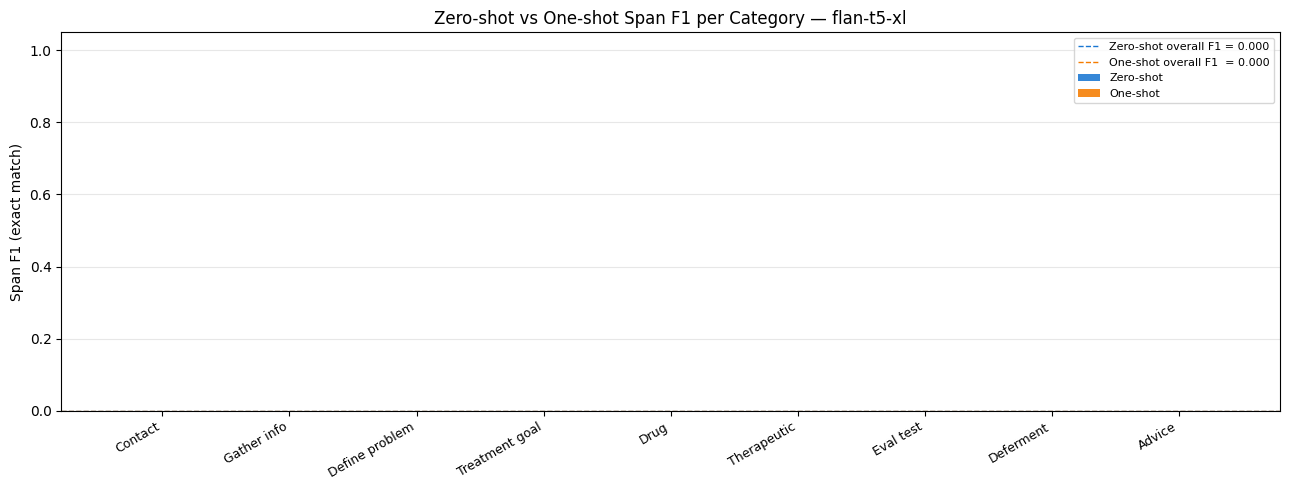

In [11]:
import matplotlib.pyplot as plt
import numpy as np

CATEGORY_NAMES_SHORT = [
    "Contact", "Gather info", "Define problem", "Treatment goal",
    "Drug", "Therapeutic", "Eval test", "Deferment", "Advice",
]

# Zero-shot vs one-shot F1 per category (exact match)
zero_f1 = [results_zero_em["per_cat"][c]["f1"] for c in range(1, 10)]
one_f1  = [results_one_em["per_cat"][c]["f1"]  for c in range(1, 10)]

x = np.arange(9)
w = 0.36

fig_cmp, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w/2, zero_f1, w, label="Zero-shot", color="#1976D2", alpha=0.88)
ax.bar(x + w/2, one_f1,  w, label="One-shot",  color="#F57C00", alpha=0.88)

ax.axhline(results_zero_em["overall"]["f1"], color="#1976D2", linestyle="--", linewidth=1,
           label=f"Zero-shot overall F1 = {results_zero_em['overall']['f1']:.3f}")
ax.axhline(results_one_em["overall"]["f1"],  color="#F57C00", linestyle="--", linewidth=1,
           label=f"One-shot overall F1  = {results_one_em['overall']['f1']:.3f}")

ax.set_xticks(x)
ax.set_xticklabels(CATEGORY_NAMES_SHORT, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Span F1 (exact match)")
ax.set_ylim(0, 1.05)
ax.set_title(f"Zero-shot vs One-shot Span F1 per Category — {MODEL_NAME.split('/')[-1]}")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

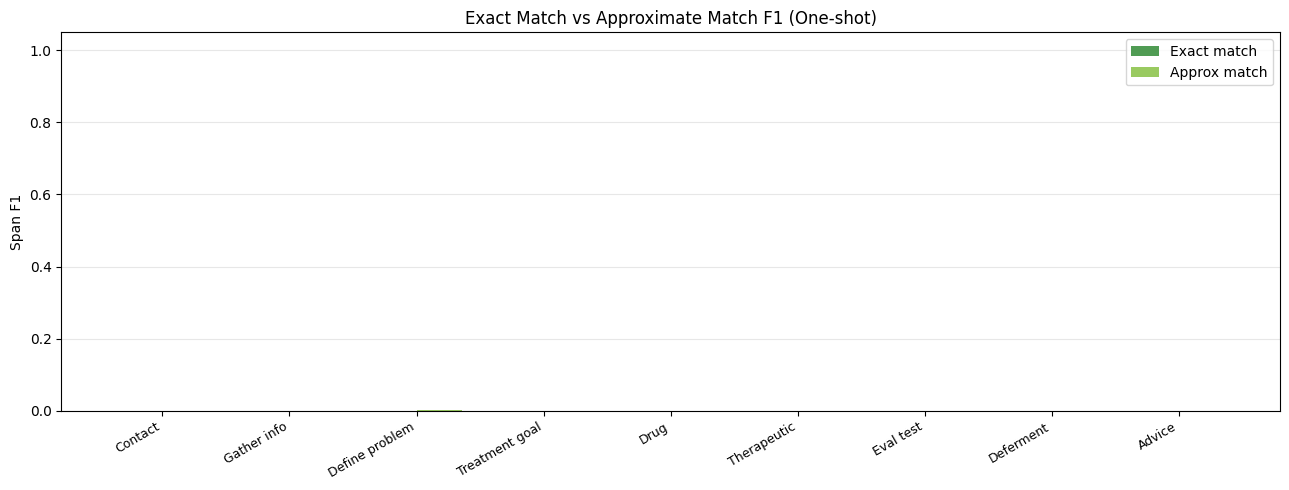

In [12]:
# EM vs Approx-M for one-shot (shows how strict the exact-match metric is)
one_em_f1     = [results_one_em["per_cat"][c]["f1"]     for c in range(1, 10)]
one_approx_f1 = [results_one_approx["per_cat"][c]["f1"] for c in range(1, 10)]

fig_method, ax2 = plt.subplots(figsize=(13, 5))
ax2.bar(x - w/2, one_em_f1,     w, label="Exact match",   color="#388E3C", alpha=0.88)
ax2.bar(x + w/2, one_approx_f1, w, label="Approx match",  color="#8BC34A", alpha=0.88)

ax2.set_xticks(x)
ax2.set_xticklabels(CATEGORY_NAMES_SHORT, rotation=30, ha="right", fontsize=9)
ax2.set_ylabel("Span F1")
ax2.set_ylim(0, 1.05)
ax2.set_title("Exact Match vs Approximate Match F1 (One-shot)")
ax2.legend()
ax2.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# README-ready markdown table comparing all four conditions

header = "| Category | Zero EM | Zero Approx | One EM | One Approx |"
sep    = "|---|---|---|---|---|"
print(header)
print(sep)
for c in range(1, 10):
    ze = results_zero_em["per_cat"][c]["f1"]
    za = results_zero_approx["per_cat"][c]["f1"]
    oe = results_one_em["per_cat"][c]["f1"]
    oa = results_one_approx["per_cat"][c]["f1"]
    print(f"| {CATEGORY_NAMES_SHORT[c-1]} | {ze:.3f} | {za:.3f} | {oe:.3f} | {oa:.3f} |")
print(sep)
ze = results_zero_em["overall"]["f1"]
za = results_zero_approx["overall"]["f1"]
oe = results_one_em["overall"]["f1"]
oa = results_one_approx["overall"]["f1"]
print(f"| **Overall** | **{ze:.3f}** | **{za:.3f}** | **{oe:.3f}** | **{oa:.3f}** |")

| Category | Zero EM | Zero Approx | One EM | One Approx |
|---|---|---|---|---|
| Contact | 0.000 | 0.000 | 0.000 | 0.000 |
| Gather info | 0.000 | 0.000 | 0.000 | 0.000 |
| Define problem | 0.000 | 0.000 | 0.000 | 0.001 |
| Treatment goal | 0.000 | 0.000 | 0.000 | 0.000 |
| Drug | 0.000 | 0.003 | 0.000 | 0.000 |
| Therapeutic | 0.000 | 0.000 | 0.000 | 0.000 |
| Eval test | 0.000 | 0.000 | 0.000 | 0.000 |
| Deferment | 0.000 | 0.000 | 0.000 | 0.000 |
| Advice | 0.000 | 0.000 | 0.000 | 0.000 |
|---|---|---|---|---|
| **Overall** | **0.000** | **0.001** | **0.000** | **0.000** |


In [ ]:
DRIVE_FIGS_DIR = DRIVE_DATA_DIR / "readme_figures"
DRIVE_FIGS_DIR.mkdir(parents=True, exist_ok=True)

saves = {
    "phase3_zero_vs_one_shot.png": fig_cmp,
    "phase3_em_vs_approx.png":     fig_method,
}
for fname, fig in saves.items():
    dest = DRIVE_FIGS_DIR / fname
    fig.savefig(dest, dpi=150, bbox_inches="tight")
    print(f"Saved: {dest}")